# CECS 381 - Programming Assignment 1
## Units 1-3: Simulation & Naive Bayes

**Name:** Carlos Aguilera

**Student ID:** 032455616

Summer 2026 | Due: July 23, 2026

Only using: Python standard library, numpy, and matplotlib.

In [64]:
import random
import numpy as np
import csv
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

## Problem 1: Estimate, by simulation, the probability that in a room of `n` people at least two share a birthday. Assume 365 equally likely days, no leap years.

### 1(a) - Simulation

In [65]:
def simulate_birthday(n, trials):
    """
    Sample n birthdays per trial and return the empirical probability
    that at least two people share a birthday.

    n      = number of people in the room
    trials = how many random rooms to simulate
    """
    count = 0

    for _ in range(trials):
        birthdays = [random.randint(1, 365) for _ in range(n)]
        if len(set(birthdays)) < n:
            count += 1

    return count / trials

### 1(b) - Theory + comparison table

In [66]:
def theoretical(n):
    """
    Return the exact probability of at least one shared birthday:
        1 - product over k=0..n-1 of (365 - k) / 365
    """
    prob = 1.0

    for k in range(n):
        prob *= (365 - k) / 365

    return 1 - prob

In [67]:
# Print a table comparing simulation vs theory for n = 5, 10, ..., 50

trials = 10000

for n in range(5, 51, 5):
    print(n, simulate_birthday(n, trials), theoretical(n))

5 0.0272 0.02713557369979347
10 0.1199 0.11694817771107768
15 0.2662 0.25290131976368646
20 0.4065 0.41143838358058027
25 0.5779 0.568699703969464
30 0.7072 0.7063162427192688
35 0.8131 0.8143832388747153
40 0.8901 0.891231809817949
45 0.9423 0.940975899465775
50 0.9706 0.9703735795779884


### 1(c) - Smallest n where theory > 0.5, and plot

smallest n where theory > 0.5: 23


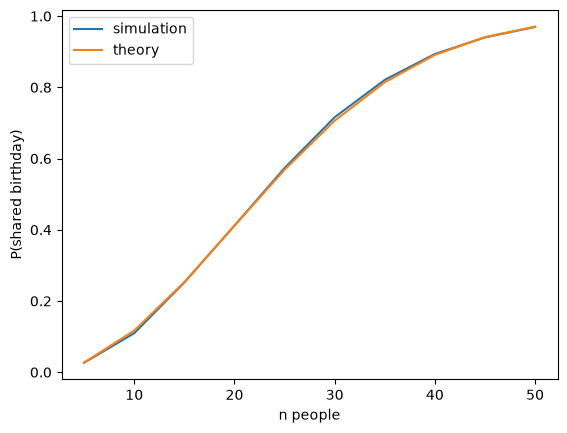

In [68]:
# find the smallest n where the theoretical probability goes above 0.5
n = 1
while theoretical(n) <= 0.5:
    n += 1

print("smallest n where theory > 0.5:", n)

# plot both curves versus n
ns = range(5, 51, 5)
sim_curve = [simulate_birthday(k, trials) for k in ns]
theory_curve = [theoretical(k) for k in ns]

plt.plot(ns, sim_curve, label='simulation')
plt.plot(ns, theory_curve, label='theory')
plt.xlabel('n people')
plt.ylabel('P(shared birthday)')
plt.legend()
plt.show()

## Problem 2: Monte Carlo probability with dice

### 2(a) - Sum of two dice

Roll two fair dice N = 10^6 times. Estimate the PMF of the sum (2 through 12) and compare P(sum = 7) with the exact value 1/6.

In [69]:
def dice_sum_pmf(N):
    """
    Roll two dice N times and return the estimated probability of each
    sum from 2 to 12 (for example, as a dictionary sum -> probability).
    """
    die1 = np.random.randint(1, 7, N)
    die2 = np.random.randint(1, 7, N)
    sums = die1 + die2

    pmf = {}
    for s in range(2, 13):
        pmf[s] = np.sum(sums == s) / N

    return pmf

In [70]:
pmf = dice_sum_pmf(10**6)

for s in range(2, 13):
    print(s, pmf[s])

print()
print("estimated P(sum = 7):", pmf[7])
print("exact P(sum = 7):", 1 / 6)

2 0.027437
3 0.055544
4 0.083627
5 0.110789
6 0.139488
7 0.166445
8 0.139289
9 0.111227
10 0.082888
11 0.055387
12 0.027879

estimated P(sum = 7): 0.166445
exact P(sum = 7): 0.16666666666666666


### 2(b) - At least one six in four rolls

Compare with the exact value 1 - (5/6)^4.

In [71]:
def prob_at_least_one_six(N):
    """
    Estimate the probability of rolling at least one six in four rolls
    of a single die, using N trials.
    """
    count = 0

    for _ in range(N):
        rolls = [random.randint(1, 6) for _ in range(4)]
        if 6 in rolls:
            count += 1

    return count / N

In [72]:
print("estimated:", prob_at_least_one_six(100000))
print("exact:", 1 - (5 / 6) ** 4)

estimated: 0.52017
exact: 0.5177469135802468


## Problem 3: Naive Bayes spam classifier

Using `spam.csv` (each row: a label ham/spam and a message), build a multinomial Naive Bayes classifier from scratch. No scikit-learn.

### 3(a) - Load, tokenize, and split the data

In [73]:
def load_data(path):
    """
    Load spam.csv. Return a list of (label, message) pairs
    where label is 'ham' or 'spam'.
    """

    data = []
    with open(path, encoding="latin-1") as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # The column names are 'v1' (label), 'v2' (message)
            data.append((row['v1'], row['v2']))

    return data


def tokenize(message):
    """
    Lowercase a message and split it into a list of words.
    """
    return message.lower().split()


def train_test_split(data):
    """
    Shuffle the data with a fixed seed and split into
    80% train / 20% test. Return (train, test).
    """
    random.shuffle(data)
    size = len(data)

    train = data[:int(size * 0.8)]
    test = data[int(size * 0.2):]

    return train, test

### 3(b) - Train and classify with multinomial Naive Bayes + Laplace smoothing

In [74]:
def train_naive_bayes(train_data):
    """
    Estimate the model from the training data:
      - class priors: P(spam), P(ham)
      - per-class word likelihoods with add-one (Laplace) smoothing
      - the vocabulary of all words seen in training
    Return whatever the classify function needs (e.g. a dict).
    """
    priors = {}
    word_counts = {'ham': {}, 'spam': {}}
    total_words = {'ham': 0, 'spam': 0}
    vocab = set()

    # count messages per class and words per class
    for label, message in train_data:
        priors[label] = priors.get(label, 0) + 1

        for word in tokenize(message):
            word_counts[label][word] = word_counts[label].get(word, 0) + 1
            total_words[label] += 1
            vocab.add(word)

    # turn the message counts into prior probabilities
    for label in priors:
        priors[label] = priors[label] / len(train_data)

    model = {
        'priors': priors,
        'word_counts': word_counts,
        'total_words': total_words,
        'vocab': vocab,
    }

    return model


def classify(model, message):
    """
    Classify one message as 'spam' or 'ham' using log-probabilities.
    """
    priors = model['priors']
    word_counts = model['word_counts']
    total_words = model['total_words']
    vocab_size = len(model['vocab'])

    scores = {}

    for label in priors:
        # start with the log of the prior
        score = np.log(priors[label])

        for word in tokenize(message):
            # skip words we never saw in training
            if word not in model['vocab']:
                continue

            # add-one (Laplace) smoothing
            count = word_counts[label].get(word, 0)
            likelihood = (count + 1) / (total_words[label] + vocab_size)
            score += np.log(likelihood)

        scores[label] = score

    # pick the label with the higher score
    if scores['spam'] > scores['ham']:
        return 'spam'
    else:
        return 'ham'

### 3(c) - Accuracy, precision, recall + written answer

In [75]:
def evaluate(model, test_data):
    """
    Classify every test message and report accuracy, plus precision
    and recall for the spam class.
    """
    correct = 0
    tp = 0  # predicted spam, actually spam
    fp = 0  # predicted spam, actually ham
    fn = 0  # predicted ham, actually spam

    for label, message in test_data:
        prediction = classify(model, message)

        if prediction == label:
            correct += 1

        if prediction == 'spam' and label == 'spam':
            tp += 1
        if prediction == 'spam' and label == 'ham':
            fp += 1
        if prediction == 'ham' and label == 'spam':
            fn += 1

    accuracy = correct / len(test_data)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    print("accuracy:", accuracy)
    print("precision:", precision)
    print("recall:", recall)

In [76]:
data = load_data('spam.csv')
train, test = train_test_split(data)
model = train_naive_bayes(train)
evaluate(model, test)

accuracy: 0.990578734858681
precision: 0.9810344827586207
recall: 0.9483333333333334


### Written answer: why log-probabilities?

A message can have many words, and each word likelihood is a small number (well below 1). If we multiply all of those tiny probabilities together, the result gets extremely small and the computer eventually rounds it to 0 (this is called **floating point underflow**). Once it hits 0 we lose all the information and can't tell the two classes apart.

Taking the log fixes this. The log of a product is the sum of the logs, so instead of multiplying many tiny numbers we **add** their logs. Adding keeps the numbers in a safe range, so no underflow. And because `log` is an increasing function, whichever class has the bigger log-score also has the bigger real probability, so the final decision comes out exactly the same.